Inside my Drive there will be a directory AdvancedML/Project

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Collection of all the necessary imports




In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd
from tqdm import tqdm
from PIL import Image

Setup of the paths that bring the user to the main directory, containing the overall dataset

In [3]:
CONTENT_PATH = os.getcwd()
PROJECT_PATH = os.path.join(CONTENT_PATH, 'drive', 'MyDrive', 'AdvancedML', 'Project')

IMAGES_DIR_PATH = os.path.join(PROJECT_PATH, 'release', 'images')
TRAIN_CSV_PATH  = os.path.join(PROJECT_PATH, 'release', 'train.csv') # CSV containing train info
TEST_CSV_PATH   = os.path.join(PROJECT_PATH, 'release', 'test_episodes_release.csv') # CSV containing episodes info

This is the first class we implemented. We used this class to have a preliminary overview of the dataset, in particular the class exposes these methods:
1) EXTRACT_INFO: extract the list of train and test filename paths, and lists of train/test labels.
2) GET_DATASET_INFO: print on the console some info such as length of train set, test set, and number of unique labels of both sets.
3) SHOW_TRAIN_RANDOM_IMGS: visualize 5 random samples of the train set.
4) INSPECT_EPISODE: visualize the support images divided by class of a given episode, and also the query images.
5) CHECK_DATA_INTEGRITY: check whether there are some invalid/corrupted files.
6) PLOT_CLASS_DISTRIBUTION: to assure that all classes were balanced
7) SHOW_IMGS_FROM_CLASS: given a label, plot a certain number of train images belonging to that label
8) CHECK_CLASS_OVERLAP: check that train and test classes are disjoint (no classe in common).
9) CHECK_IMAGE_RESOLUTIONS: check some image resolutions, and see if some are different or all equal

In [4]:
class DatasetAnalyzer():


  def __init__(self, imgs_dir, train_csv_path, test_csv_path):

    self.imgs_dir = imgs_dir

    self.train_df = pd.read_csv(train_csv_path)
    self.test_df  = pd.read_csv(test_csv_path)



  def extract_info(self, df: pd.DataFrame, filename_col: str, label_col: str) -> tuple[list,list]:

        """
        This method extracts for a given csv, all the filenames associated to filename_col, and all the labels associated to label_col.
        Input:
        df --> dataframe (train_csv or test_episodes_csv)
        filename_col ---> column name containing filenames, relative to the df inserted
        label_col ---> column name containing labels, relative to the df inserted

        Output ---> a list containing all the paths to reach the filenames, and a list containing the labels associated to those filenames
        """

        img_paths = []
        labels    = []

        for row in df.itertuples():

            filename = getattr(row, filename_col)
            label    = getattr(row, label_col)

            img_path = os.path.join(self.imgs_dir, filename)

            img_paths.append(img_path)
            labels.append(label)

        return img_paths, labels



  def get_dataset_info(self):

        """
        This method exploits the previous one to print on the console some basic information about the dataset, such as the length of the train and test set,
        and the number of labels contained in both of them
        """

        train_img_paths, train_labels = self.extract_info(
            self.train_df,
            "filename",
            "label"
        )

        test_img_paths, test_labels = self.extract_info(
            self.test_df,
            "filename",
            "label"
        )

        print(f"TRAIN IMAGES: {len(train_img_paths)}")
        print(f"TRAIN CLASSES: {len(set(train_labels))}")

        print(f"TEST IMAGES: {len(test_img_paths)}")
        print(f"TEST CLASSES: {pd.Series(test_labels).nunique(dropna=True)}")



  def show_train_random_imgs(self):

        """
        This method shows 5 random images in the train set
        """

        # Extract 5 random indeces
        train_idxs = np.arange(1,5001,1)
        random_idxs = np.random.randint(1, 5001, size=5)

        fig, axs = plt.subplots(1, 5, figsize=(12,12))
        for i in range(5):
          IMG_PATH = os.path.join(IMAGES_DIR_PATH, os.listdir(IMAGES_DIR_PATH)[random_idxs[i]])
          img = cv.imread(IMG_PATH)
          axs[i].imshow(img)
          axs[i].set_axis_off()



  def inspect_episode(self, episode_idx: int):

        """
        This method takes as input an index for an episode, and returns back a visualization of all the support images divided by class,
        and all the query images
        """

        episode_df = self.test_df[self.test_df['episode_id'] == episode_idx]

        support_set = episode_df[episode_df.role == 'support']
        query_set = episode_df[episode_df.role == 'query']

        classes = support_set.label.unique().astype(int)
        print(f"Episode {episode_idx} classes: {classes}")

        fig, axs = plt.subplots(len(classes), len(support_set)//len(classes), figsize=(12,12))
        fig.suptitle(f"Episode {episode_idx} - SUPPORT", fontsize=16, color='green')

        for i, cls in enumerate(classes):
          subset = support_set[support_set.label == cls].reset_index(drop=True)

          for j in range(5):
            filename = subset.iloc[j]['filename']
            file_path = os.path.join(self.imgs_dir,filename)

            img = cv.imread(file_path)
            img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

            ax = axs[i,j]
            ax.imshow(img)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('green')
                spine.set_linewidth(2)

            ax.set_xticks([])
            ax.set_yticks([])


        fig1, axs1 = plt.subplots(5,5,figsize=(12,12))
        fig1.suptitle(f"Episode {episode_idx} - QUERY", fontsize=16, color='blue')
        axs1 = axs1.flatten()

        for z in range(axs1.shape[0]):
          filename = query_set.iloc[z]['filename']
          file_path = os.path.join(self.imgs_dir,filename)

          img = cv.imread(file_path)
          img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

          ax = axs1[z]
          ax.imshow(img)
          for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('blue')
                spine.set_linewidth(2)

          ax.set_xticks([])
          ax.set_yticks([])

        plt.tight_layout()
        plt.show()



  def check_data_integrity(self):

        """
        This method checks whether there are images that are corrupted or not readable. If everything is ok, the console will display a message
        of successfull integrity check
        """

        corrupted_files = []
        all_files = pd.concat([self.train_df['filename'], self.test_df['filename']]).unique()

        print("Verifying integrity of images...")
        for filename in tqdm(all_files):
            img = cv.imread(os.path.join(self.imgs_dir, filename))
            if img is None:
                corrupted_files.append(filename)

        if len(corrupted_files) > 0:
            print(f"ATTENTION: {len(corrupted_files)} corrupted file or non readable found!")
            return corrupted_files
        else:
            print("All images are readable. Dataset intact.")



  def plot_class_distribution(self):

        """
        This method was built to check whether there are some classes imposing on others (numericaly speaking)
        """

        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

        # Train
        self.train_df['label'].value_counts().plot(kind='bar', ax=ax[0], color='salmon')
        ax[0].set_title('TRAIN classes distribution')
        ax[0].set_xticks([])

        # Test
        self.test_df['label'].value_counts().plot(kind='bar', ax=ax[1], color='skyblue')
        ax[1].set_title('TEST classes distribution')
        ax[1].set_xticks([])

        plt.tight_layout()
        plt.show()



  def show_imgs_from_class(self, label_id: int, n_imgs=10):

        """
        This method visualize n_imgs belonging to the class label_id
        """

        print(np.array(sorted(self.train_df.label.unique())).astype(int)) # print of classes available

        assert label_id in self.train_df.label.unique(), 'Class not found'

        class_df = self.train_df[self.train_df['label'] == label_id].head(n_imgs)

        fig, axs = plt.subplots(1, n_imgs, figsize=(n_imgs*2, 2))
        for i, (_, row) in enumerate(class_df.iterrows()):
            img = cv.cvtColor(cv.imread(os.path.join(self.imgs_dir, row['filename'])), cv.COLOR_BGR2RGB)
            axs[i].imshow(img)
            axs[i].set_axis_off()
        plt.show()



  def check_class_overlap(self):

        """
        Checks whether some classes of the train set overlap with those of the test set.
        """

        train_classes = set(self.train_df['label'].unique())
        test_classes = set(self.test_df['label'].unique())

        overlap = train_classes.intersection(test_classes)

        if not overlap:
            print("There are no common classes between train and test!.")
            print("The dataset is completely disjoint")

        else:
            print(f"Attention: {len(overlap)} classe in common were found!")
            print(f"Superimposed classes: {sorted(list(overlap))}")
            return overlap



  def check_image_resolutions(self):

        # Uniamo i file per analizzare tutto il dataset
        all_files = pd.concat([self.train_df['filename'], self.test_df['filename']]).unique()

        resolutions = set()
        print("Resolution analysis in progress...")

        for i,filename in enumerate(all_files):
            img_path = os.path.join(self.imgs_dir, filename)
            with Image.open(img_path) as img:
              w, h = img.size
              resolutions.add((w, h))

            if i > 20:
              break

        if len(resolutions) == 1:
            res = list(resolutions)[0]
            print(f"Tutte le immagini hanno la stessa risoluzione: {res[0]}x{res[1]}")
        else:
            print(f"Il dataset ha {len(resolutions)} risoluzioni diverse.")
            print(f"Risoluzioni trovate: {sorted(list(resolutions))}")

In [5]:
analyzer = DatasetAnalyzer(IMAGES_DIR_PATH, TRAIN_CSV_PATH, TEST_CSV_PATH)

In [6]:
analyzer.get_dataset_info()

TRAIN IMAGES: 5000
TRAIN CLASSES: 250
TEST IMAGES: 1000
TEST CLASSES: 100


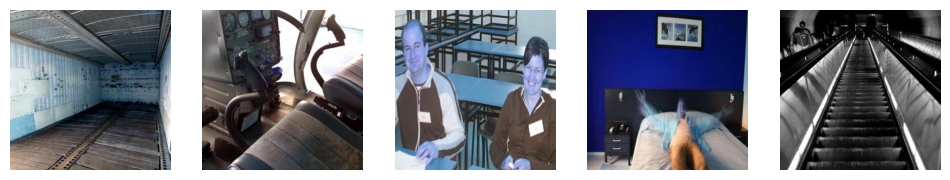

In [7]:
analyzer.show_train_random_imgs()

In [8]:
analyzer.inspect_episode(0)

Output hidden; open in https://colab.research.google.com to view.

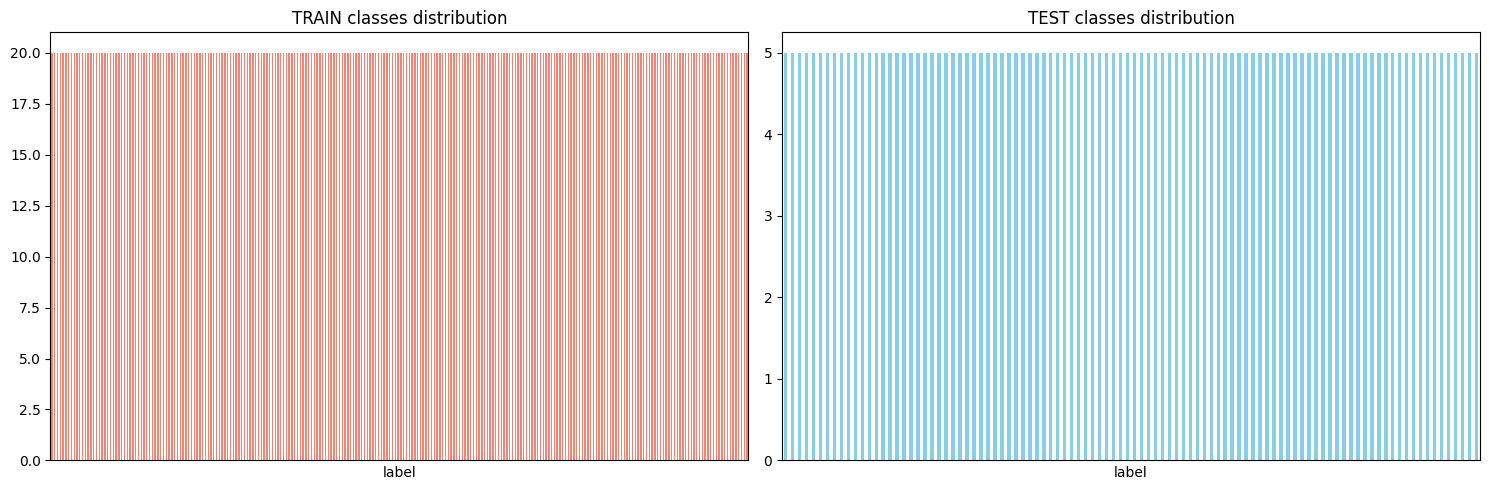

In [9]:
analyzer.plot_class_distribution()

[  0   1   2   4   5   6   7   8   9  10  11  14  17  18  19  20  21  25
  26  27  29  30  31  32  34  37  38  41  42  43  45  48  50  53  54  55
  58  59  60  61  62  64  65  66  67  68  69  72  74  75  76  77  78  80
  82  84  85  86  88  89  90  91  92  93  94  95  96  97  99 100 102 103
 104 105 106 109 113 115 118 120 121 122 123 124 127 128 129 130 131 132
 133 139 141 143 144 145 146 147 149 151 152 153 154 155 156 157 158 159
 162 163 164 165 167 168 169 170 171 173 175 177 178 179 180 182 184 187
 188 190 191 192 195 196 197 198 199 200 201 203 206 207 208 209 210 211
 212 213 215 217 218 220 221 222 223 224 225 226 227 228 230 231 233 237
 238 239 240 241 242 243 244 245 246 247 248 249 250 251 253 254 256 257
 259 260 261 262 263 264 265 266 267 268 269 271 272 275 276 277 280 281
 284 285 286 288 289 290 291 292 293 294 297 298 299 304 305 306 307 311
 312 314 315 317 318 320 321 322 323 325 326 328 329 333 334 336 337 339
 340 341 342 343 344 345 348 350 353 354 356 359 36

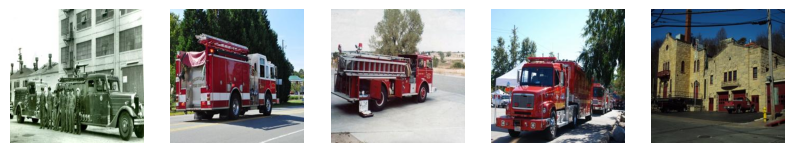

In [10]:
analyzer.show_imgs_from_class(144, 5)

In [11]:
analyzer.check_class_overlap()

There are no common classes between train and test!.
The dataset is completely disjoint


In [12]:
analyzer.check_image_resolutions()

Resolution analysis in progress...
Tutte le immagini hanno la stessa risoluzione: 256x256
